# H2O `f0.000 -> f0.350` (`nauto`) Run Analysis

This notebook analyzes:

`/gpfs/scratch/ahurtado/project_data/freq_dev/data/H2O/mra-f0.000-f0.350-nauto/f0-f0350_pauto/task_1/molresponse`

Focus:
- point-level convergence by protocol and frequency
- iteration counts and residual trends
- restart provenance
- subgroup log status to diagnose the non-completing run


In [1]:
from pathlib import Path
import json
import re
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUN_DIR = Path('/gpfs/scratch/ahurtado/project_data/freq_dev/data/H2O/mra-f0.000-f0.350-nauto/f0-f0350_pauto/task_1/molresponse')
META_PATH = RUN_DIR / 'response_metadata.json'

assert RUN_DIR.exists(), f'Missing RUN_DIR: {RUN_DIR}'
assert META_PATH.exists(), f'Missing metadata: {META_PATH}'

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 12

print('RUN_DIR:', RUN_DIR)
print('response_metadata.json size:', META_PATH.stat().st_size)


RUN_DIR: /gpfs/scratch/ahurtado/project_data/freq_dev/data/H2O/mra-f0.000-f0.350-nauto/f0-f0350_pauto/task_1/molresponse
response_metadata.json size: 110180


In [2]:
with META_PATH.open() as f:
    meta = json.load(f)

states = meta.get('states', {})

rows = []
prov_rows = []
for state, sdata in states.items():
    protocols = sdata.get('protocols', {})
    for protocol, pdata in protocols.items():
        converged = pdata.get('converged', {})
        saved = pdata.get('saved', {})
        removed = pdata.get('removed', {}) if isinstance(pdata.get('removed', {}), dict) else {}
        diag = pdata.get('solver_diagnostics', {})
        prov = pdata.get('restart_provenance', {})

        freqs = sorted(set(converged.keys()) | set(saved.keys()) | set(diag.keys()) | set(prov.keys()), key=lambda x: float(x))
        for fk in freqs:
            d = diag.get(fk, {})
            p = prov.get(fk, {})
            rows.append({
                'state': state,
                'protocol': protocol,
                'frequency_key': fk,
                'frequency': float(fk),
                'converged': bool(converged.get(fk, False)),
                'saved': bool(saved.get(fk, False)),
                'removed': bool(removed.get(fk, False)),
                'iterations': d.get('iterations_performed'),
                'final_residual': d.get('final_residual_norm'),
                'final_drho': d.get('final_density_change'),
                'final_alpha': d.get('final_alpha'),
                'failure_reason': d.get('failure_reason'),
                'restart_kind': p.get('kind'),
                'restart_source_protocol': p.get('source_protocol'),
                'restart_source_frequency': p.get('source_frequency'),
                'loaded_from_disk': p.get('loaded_from_disk'),
                'promoted_from_static': p.get('promoted_from_static'),
            })


diag_df = pd.DataFrame(rows)
assert not diag_df.empty

protocol_order = sorted(diag_df['protocol'].dropna().unique(), key=float, reverse=True)  # 1e-02, 1e-04, 1e-06
final_protocol = sorted(diag_df['protocol'].dropna().unique(), key=float)[0]  # smallest threshold

print('States:', diag_df['state'].nunique())
print('Protocols (coarse->fine):', protocol_order)
print('Final protocol:', final_protocol)
print('Total points:', len(diag_df))

summary = (
    diag_df.groupby('protocol')[['converged', 'saved', 'removed']]
    .sum()
    .assign(total=lambda d: diag_df.groupby('protocol').size())
)
summary


States: 12
Protocols (coarse->fine): ['1e-02', '1e-04', '1e-06']
Final protocol: 1e-06
Total points: 99


,converged,saved,removed,total
protocol,,,,
1e-02,33,33,0,33
1e-04,31,33,0,33
1e-06,32,33,0,33


In [3]:
final_df = diag_df[diag_df['protocol'] == final_protocol].copy()
nonconv = final_df[~final_df['converged']].sort_values(['state', 'frequency'])

print('Final protocol points:', len(final_df))
print('Final protocol converged:', int(final_df['converged'].sum()))
print('Final protocol unconverged:', len(nonconv))

if len(nonconv) > 0:
    display(nonconv[['state','frequency','saved','removed','iterations','final_residual','final_drho','final_alpha','failure_reason','restart_kind']])


Final protocol points: 33
Final protocol converged: 32
Final protocol unconverged: 1


,state,frequency,saved,removed,iterations,final_residual,final_drho,final_alpha,failure_reason,restart_kind
71,Dipole_z,0.35,True,False,20,0.013669,0.02877,16.439572,unconverged_below_cutoff,same_protocol_archive


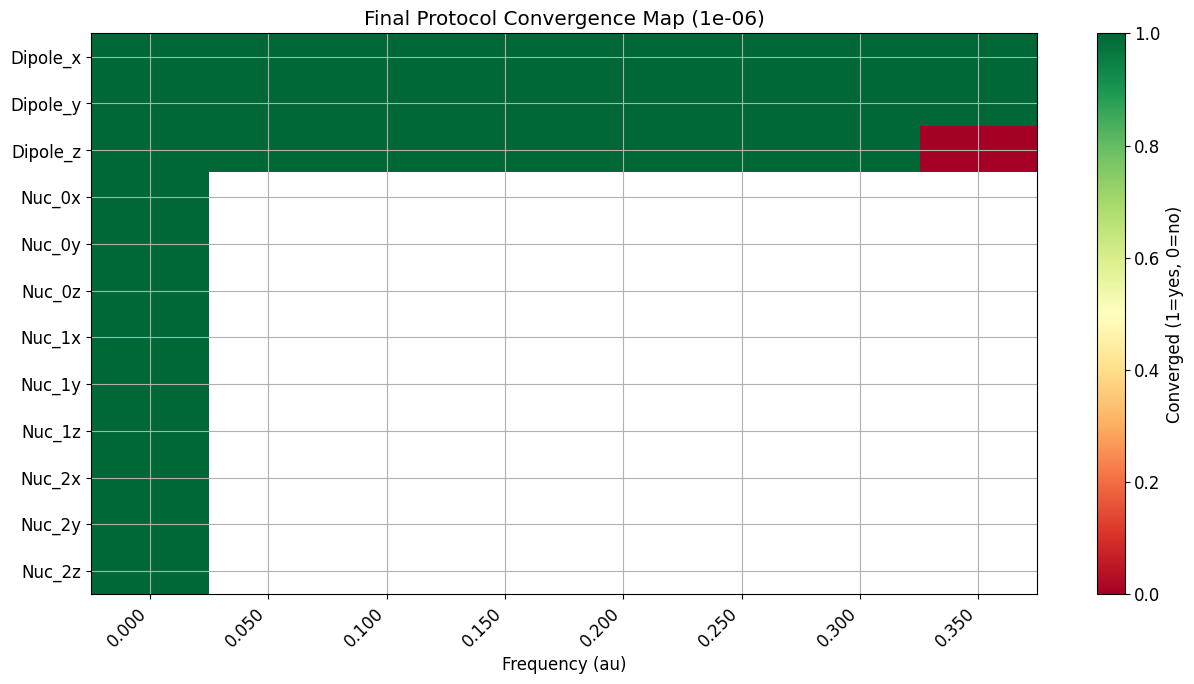

In [4]:
# Convergence map at final protocol
plot_df = final_df.copy()
plot_df['conv_int'] = plot_df['converged'].astype(int)

pivot = plot_df.pivot_table(index='state', columns='frequency', values='conv_int', aggfunc='max')
pivot = pivot.sort_index()

fig, ax = plt.subplots(figsize=(13, 7))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels([f'{x:.3f}' for x in pivot.columns], rotation=45, ha='right')
ax.set_xlabel('Frequency (au)')
ax.set_title(f'Final Protocol Convergence Map ({final_protocol})')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Converged (1=yes, 0=no)')
plt.tight_layout()
plt.show()


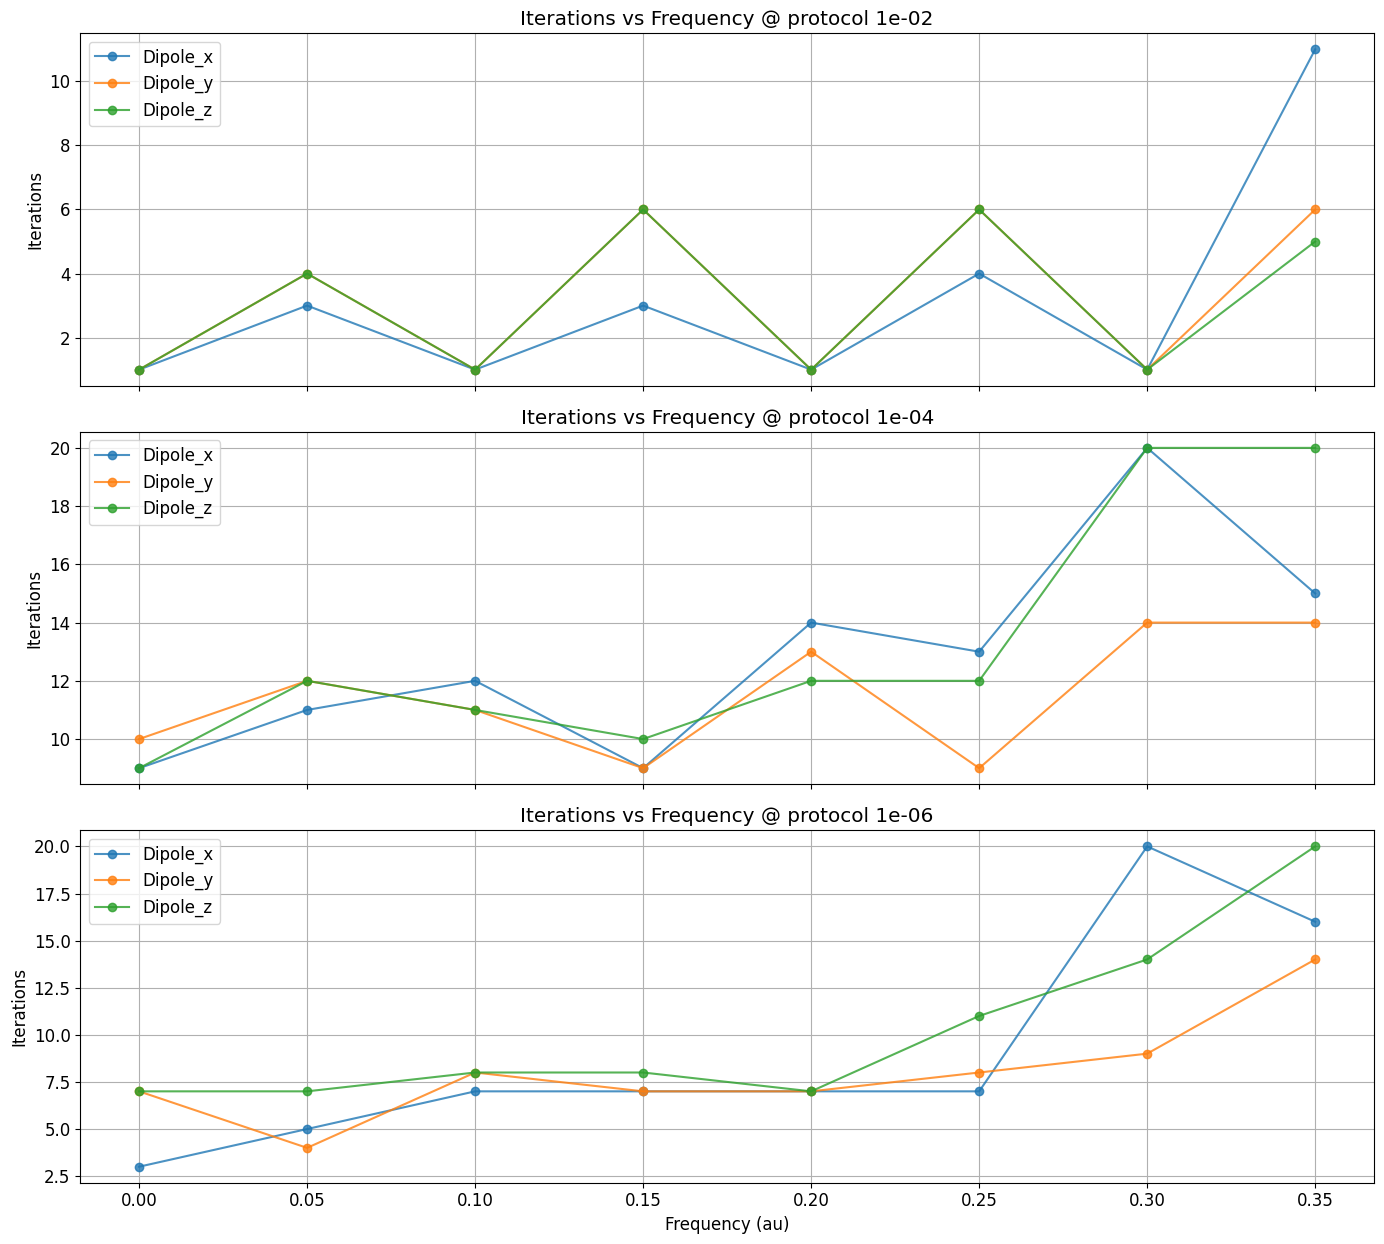

In [5]:
# Iterations vs frequency by protocol (Dipole channels)
dip = diag_df[diag_df['state'].isin(['Dipole_x','Dipole_y','Dipole_z'])].copy()

fig, axes = plt.subplots(len(protocol_order), 1, figsize=(14, 4.2*len(protocol_order)), sharex=True)
if len(protocol_order) == 1:
    axes = [axes]

for ax, p in zip(axes, protocol_order):
    d = dip[dip['protocol'] == p].sort_values('frequency')
    for state, sdf in d.groupby('state'):
        ax.plot(sdf['frequency'], sdf['iterations'], marker='o', alpha=0.8, label=state)
    ax.set_ylabel('Iterations')
    ax.set_title(f'Iterations vs Frequency @ protocol {p}')
    ax.legend(loc='upper left')

axes[-1].set_xlabel('Frequency (au)')
plt.tight_layout()
plt.show()


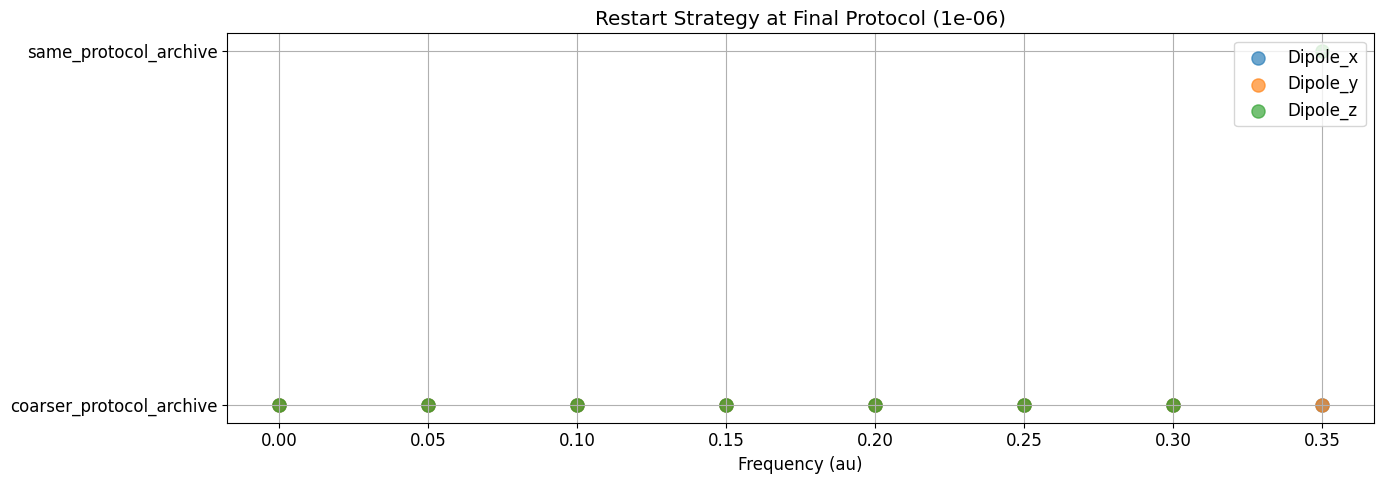

In [6]:
# Restart strategy at final protocol (Dipole channels)
plot_df = dip[dip['protocol'] == final_protocol].copy()
plot_df = plot_df.sort_values(['state','frequency'])

kinds = [k for k in plot_df['restart_kind'].dropna().unique()]
kind_to_y = {k:i for i,k in enumerate(sorted(kinds))}
plot_df['restart_y'] = plot_df['restart_kind'].map(kind_to_y)

fig, ax = plt.subplots(figsize=(14, 5))
colors = {'Dipole_x':'tab:blue', 'Dipole_y':'tab:orange', 'Dipole_z':'tab:green'}

for state, sdf in plot_df.groupby('state'):
    ax.scatter(sdf['frequency'], sdf['restart_y'], s=90, alpha=0.65, c=colors.get(state,'gray'), label=state)

ax.set_yticks(list(kind_to_y.values()))
ax.set_yticklabels(list(kind_to_y.keys()))
ax.set_xlabel('Frequency (au)')
ax.set_title(f'Restart Strategy at Final Protocol ({final_protocol})')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


In [7]:
# Parse per-iteration residual lines from subgroup logs
iter_pat = re.compile(
    r'ITERATION_RESIDUAL state=\s*(\S+)\s+protocol=\s*([0-9.eE+-]+)\s+frequency=\s*([0-9.eE+-]+)\s+iter=\s*(\d+)\s+residual=\s*([0-9.eE+-]+)\s+drho=\s*([0-9.eE+-]+)\s+alpha=\s*([0-9.eE+-]+)'
)

iter_rows = []
for lf in sorted(RUN_DIR.glob('response_console.group*.log')):
    m = re.search(r'group(\d+)\.log$', lf.name)
    gid = int(m.group(1)) if m else -1
    with lf.open(errors='ignore') as f:
        for line in f:
            mm = iter_pat.search(line)
            if mm:
                iter_rows.append({
                    'group': gid,
                    'state': mm.group(1),
                    'protocol': mm.group(2),
                    'frequency': float(mm.group(3)),
                    'iter': int(mm.group(4)),
                    'residual': float(mm.group(5)),
                    'drho': float(mm.group(6)),
                    'alpha': float(mm.group(7)),
                })

iter_df = pd.DataFrame(iter_rows)
print('iteration rows:', len(iter_df))
iter_df.head()


iteration rows: 1059


,group,state,protocol,frequency,iter,residual,drho,alpha
0,1,Nuc_0y,1.000000e-06,0.0,0,0.004466,0.004303,10361.79
1,1,Nuc_0y,1.000000e-06,0.0,1,0.009189,0.007378,10364.49
2,1,Nuc_0y,1.000000e-06,0.0,2,0.001750,0.003189,10365.45
3,1,Nuc_0y,1.000000e-06,0.0,3,0.001063,0.011927,10363.44
4,1,Nuc_0y,1.000000e-06,0.0,4,0.007032,0.013326,10365.63


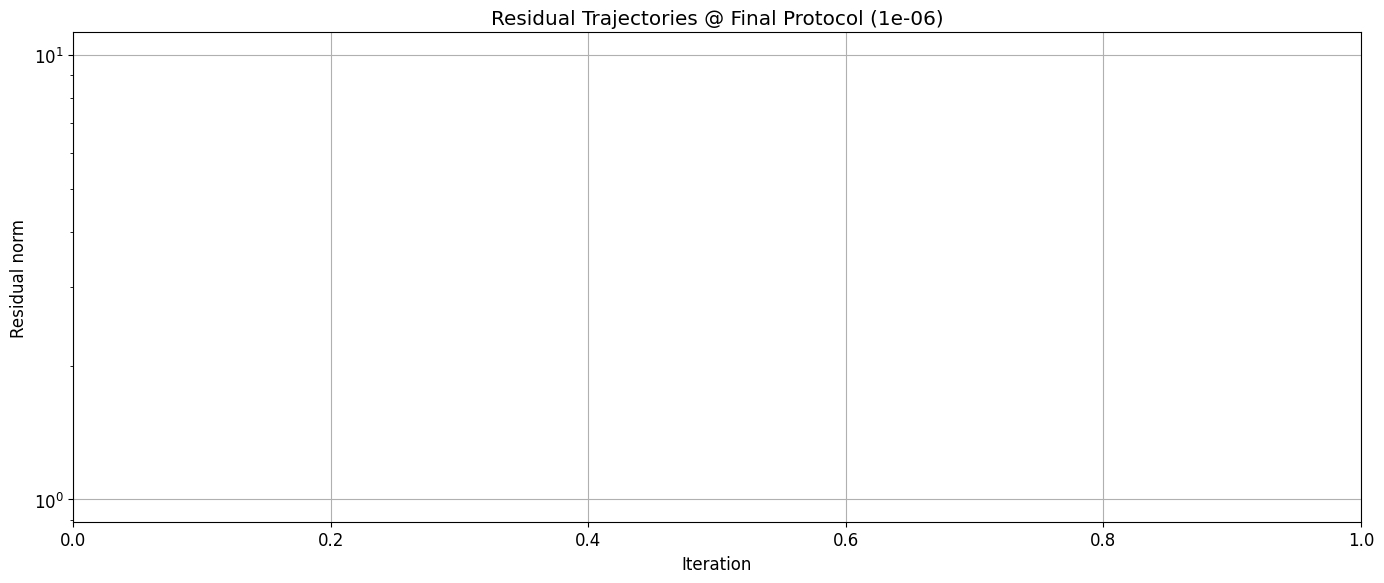

In [8]:
# Residual trajectories for final protocol Dipole channels
if not iter_df.empty:
    sel = iter_df[(iter_df['protocol'] == final_protocol) & (iter_df['state'].isin(['Dipole_x','Dipole_y','Dipole_z']))]

    fig, ax = plt.subplots(figsize=(14, 6))
    for (state, freq), sdf in sel.groupby(['state','frequency']):
        lw = 2.5 if (state == 'Dipole_z' and abs(freq - 0.35) < 1e-10) else 1.0
        alpha = 0.95 if lw > 2 else 0.35
        label = f'{state} f={freq:.3f}' if lw > 2 else None
        ax.plot(sdf['iter'], sdf['residual'], alpha=alpha, linewidth=lw, label=label)

    ax.set_yscale('log')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Residual norm')
    ax.set_title(f'Residual Trajectories @ Final Protocol ({final_protocol})')
    if ax.get_legend_handles_labels()[0]:
        ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


In [9]:
# Subgroup log checkpoint scan for hang diagnosis
markers = [
    'SUBGROUP_STAGE2_COMPLETE',
    'SUBGROUP_TAIL_DERIVED_CONTEXT_READY',
    'SUBGROUP_DERIVED_STAGE_DONE',
    'PROPERTY_STAGE_START',
    'PROPERTY_STAGE_DONE',
    'DERIVED_TIMING_SUMMARY',
]

rows = []
for lf in sorted(RUN_DIR.glob('response_console.group*.log')):
    txt = lf.read_text(errors='ignore').splitlines()
    m = re.search(r'group(\d+)\.log$', lf.name)
    gid = int(m.group(1)) if m else -1
    rec = {
        'group': gid,
        'lines': len(txt),
        'mtime': datetime.fromtimestamp(lf.stat().st_mtime),
        'last_line': txt[-1] if txt else ''
    }
    for mk in markers:
        idx = [i for i, line in enumerate(txt, start=1) if mk in line]
        rec[f'{mk}_line'] = idx[-1] if idx else np.nan
    rows.append(rec)

log_df = pd.DataFrame(rows).sort_values('group')
display(log_df[['group','mtime','SUBGROUP_STAGE2_COMPLETE_line','SUBGROUP_TAIL_DERIVED_CONTEXT_READY_line','SUBGROUP_DERIVED_STAGE_DONE_line','PROPERTY_STAGE_START_line','PROPERTY_STAGE_DONE_line','DERIVED_TIMING_SUMMARY_line']])

print('Missing tail-derived-context groups:')
print(log_df[log_df['SUBGROUP_TAIL_DERIVED_CONTEXT_READY_line'].isna()]['group'].tolist())

print('Key output files:')
for p in [RUN_DIR/'response_metadata.json', RUN_DIR/'response_log.json', RUN_DIR/'properties.json']:
    if p.exists():
        print(p.name, 'mtime=', datetime.fromtimestamp(p.stat().st_mtime), 'size=', p.stat().st_size)
    else:
        print(p.name, 'MISSING')


,group,mtime,SUBGROUP_STAGE2_COMPLETE_line,SUBGROUP_TAIL_DERIVED_CONTEXT_READY_line,SUBGROUP_DERIVED_STAGE_DONE_line,PROPERTY_STAGE_START_line,PROPERTY_STAGE_DONE_line,DERIVED_TIMING_SUMMARY_line
0,0,2026-03-06 12:07:54.752652,NaN,NaN,NaN,NaN,NaN,67.0
1,1,2026-03-10 14:32:39.459423,2438.0,1790.0,NaN,NaN,NaN,NaN
12,2,2026-03-10 14:32:39.468207,2399.0,1755.0,NaN,NaN,NaN,NaN
21,3,2026-03-10 14:32:39.468197,2493.0,1807.0,NaN,NaN,NaN,NaN
22,4,2026-03-10 14:32:39.480551,2185.0,1528.0,NaN,NaN,NaN,NaN
23,5,2026-03-10 14:32:39.480564,1876.0,1255.0,NaN,NaN,NaN,NaN
24,6,2026-03-10 14:32:39.473220,1710.0,1091.0,NaN,NaN,NaN,NaN
25,7,2026-03-10 14:32:39.473125,1945.0,1324.0,NaN,NaN,NaN,NaN
26,8,2026-03-10 14:32:39.463799,1761.0,1151.0,NaN,NaN,NaN,NaN
27,9,2026-03-10 14:32:39.463719,1776.0,1134.0,NaN,NaN,NaN,NaN


Missing tail-derived-context groups:
[0, 17, 18, 19]
Key output files:
response_metadata.json mtime= 2026-03-10 14:32:39.622112 size= 110180
response_log.json mtime= 2026-03-10 14:32:39.624203 size= 3
properties.json mtime= 2026-03-10 14:47:30.719090 size= 253446


## Notes

- This run has one visible final-protocol non-converged point in merged metadata (`Dipole_z`, `f=0.350`, `p=1e-06`).
- `properties.json` is missing even though per-group component files exist, which supports that final merge/finalization did not complete.
- Use the subgroup marker table above to see where each group stopped.
